In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')

df.head()


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


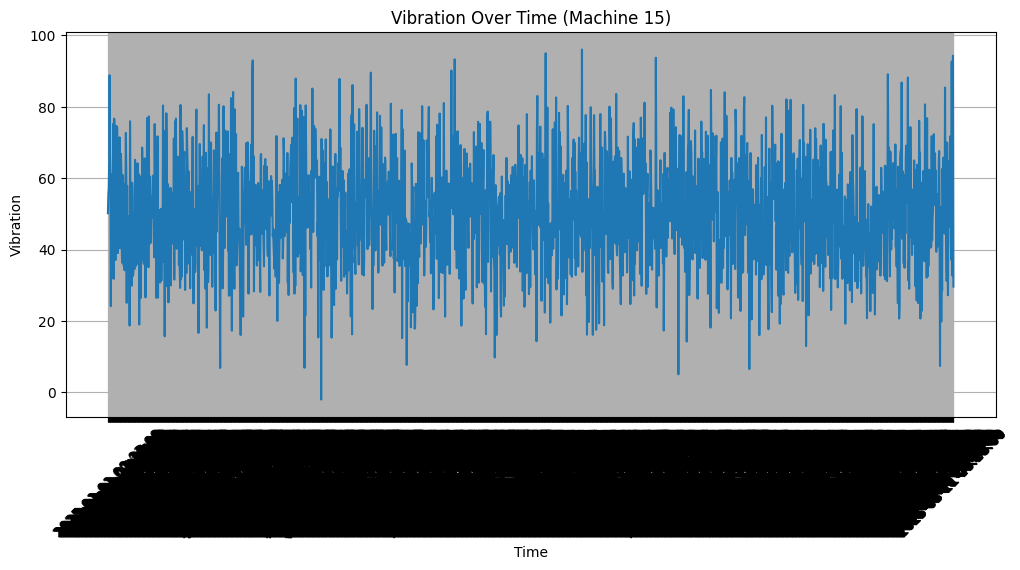

In [3]:
# Select one machine
machine = df[df["machine_id"] == 15]

# Plot vibration over time
plt.figure(figsize=(12,5))
plt.plot(machine["timestamp"], machine["vibration"])
plt.title("Vibration Over Time (Machine 15)")
plt.xlabel("Time")
plt.ylabel("Vibration")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [4]:
machine[[
    "timestamp",
    "vibration",
    "failure_type"
]].tail(20)

,timestamp,vibration,failure_type
99087,2025-03-10 19:27:00,49.74,Normal
99146,2025-03-10 20:26:00,70.05,Normal
99147,2025-03-10 20:27:00,40.19,Normal
99156,2025-03-10 20:36:00,31.17,Normal
99162,2025-03-10 20:42:00,69.98,Normal
99244,2025-03-10 22:04:00,57.71,Normal
99305,2025-03-10 23:05:00,27.21,Normal
99347,2025-03-10 23:47:00,54.83,Normal
99380,2025-03-11 00:20:00,64.85,Normal
99482,2025-03-11 02:02:00,59.40,Normal


In [5]:
machine[[
    "timestamp",
    "vibration",
    "downtime_risk"
]].tail(20)

,timestamp,vibration,downtime_risk
99087,2025-03-10 19:27:00,49.74,0.0
99146,2025-03-10 20:26:00,70.05,0.0
99147,2025-03-10 20:27:00,40.19,0.0
99156,2025-03-10 20:36:00,31.17,0.0
99162,2025-03-10 20:42:00,69.98,0.0
99244,2025-03-10 22:04:00,57.71,0.0
99305,2025-03-10 23:05:00,27.21,0.0
99347,2025-03-10 23:47:00,54.83,0.0
99380,2025-03-11 00:20:00,64.85,0.0
99482,2025-03-11 02:02:00,59.40,0.0


In [6]:
machine[[
    "timestamp",
    "predicted_remaining_life",
    "downtime_risk"
]].tail(20)

,timestamp,predicted_remaining_life,downtime_risk
99087,2025-03-10 19:27:00,408,0.0
99146,2025-03-10 20:26:00,461,0.0
99147,2025-03-10 20:27:00,449,0.0
99156,2025-03-10 20:36:00,317,0.0
99162,2025-03-10 20:42:00,337,0.0
99244,2025-03-10 22:04:00,28,0.0
99305,2025-03-10 23:05:00,18,0.0
99347,2025-03-10 23:47:00,141,0.0
99380,2025-03-11 00:20:00,487,0.0
99482,2025-03-11 02:02:00,205,0.0


In [7]:
corr = df[[
    "temperature",
    "vibration",
    "humidity",
    "pressure",
    "energy_consumption",
    "downtime_risk",
    "maintenance_required",
    "predicted_remaining_life",
    "anomaly_flag"
]].corr()

print(corr["maintenance_required"].sort_values(ascending=False))

maintenance_required        1.000000
anomaly_flag                0.631728
downtime_risk               0.631726
temperature                 0.283021
vibration                   0.113072
energy_consumption          0.001384
pressure                   -0.001945
humidity                   -0.003815
predicted_remaining_life   -0.342990
Name: maintenance_required, dtype: float64


In [8]:
columns = ["temperature", "vibration",
           "humidity", "pressure", "energy_consumption", "predicted_remaining_life", "anomaly_flag", "downtime_risk"]
for col in columns:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,0.498437,0.349454,0.9992,0.6825,0.368889,1,0.0,0.210843,Normal,0.0,0
1,2025-01-01 00:01:00,29,0.377822,0.568187,0.1188,0.6600,0.042222,1,0.0,0.640562,Normal,0.0,0
2,2025-01-01 00:02:00,15,0.733765,0.514096,0.8412,0.0000,0.442222,1,1.0,0.036145,Normal,1.0,1
3,2025-01-01 00:03:00,43,0.640815,0.418214,0.0068,0.5375,0.991111,1,1.0,0.018072,Normal,1.0,1
4,2025-01-01 00:04:00,8,0.425628,0.441439,0.5342,0.4200,0.028889,2,0.0,0.128514,Vibration Issue,0.0,1


In [9]:
df = df.sort_values(["machine_id", "timestamp"])

df["vibration_rolling_mean"] = (df.groupby("machine_id")["vibration"].transform( # This will group by machine_id to calculate rolling mean for each machine
    lambda x: x.rolling(window=60, min_periods=1).mean()))

df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,vibration_rolling_mean
97,2025-01-01 01:37:00,1,0.312999,0.497899,0.6026,0.1550,0.813333,1,0.0,0.726908,Normal,0.0,0,0.497899
102,2025-01-01 01:42:00,1,0.408959,0.655207,0.4114,0.0125,0.413333,1,0.0,0.220884,Normal,0.0,0,0.576553
133,2025-01-01 02:13:00,1,0.310105,0.685843,0.6094,0.3100,0.988889,1,0.0,0.383534,Normal,0.0,0,0.612983
139,2025-01-01 02:19:00,1,0.607478,0.538238,0.4158,0.5200,0.388889,1,0.0,0.602410,Normal,0.0,0,0.594297
185,2025-01-01 03:05:00,1,0.507466,0.508289,0.5398,0.3850,0.502222,1,0.0,0.253012,Normal,0.0,0,0.577095


In [10]:
df["temperature_12h_max"] = (
    df.groupby("machine_id")["temperature"] # This will group by machine_id 
      .transform(lambda x: x.rolling(window=60, min_periods=1).max())
)
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,vibration_rolling_mean,temperature_12h_max
97,2025-01-01 01:37:00,1,0.312999,0.497899,0.6026,0.1550,0.813333,1,0.0,0.726908,Normal,0.0,0,0.497899,0.312999
102,2025-01-01 01:42:00,1,0.408959,0.655207,0.4114,0.0125,0.413333,1,0.0,0.220884,Normal,0.0,0,0.576553,0.408959
133,2025-01-01 02:13:00,1,0.310105,0.685843,0.6094,0.3100,0.988889,1,0.0,0.383534,Normal,0.0,0,0.612983,0.408959
139,2025-01-01 02:19:00,1,0.607478,0.538238,0.4158,0.5200,0.388889,1,0.0,0.602410,Normal,0.0,0,0.594297,0.607478
185,2025-01-01 03:05:00,1,0.507466,0.508289,0.5398,0.3850,0.502222,1,0.0,0.253012,Normal,0.0,0,0.577095,0.607478


In [11]:
corr = df[[
    "temperature_12h_max",
    "vibration_rolling_mean",
    "maintenance_required"
]].corr()

print(corr["maintenance_required"].sort_values(ascending=False))

maintenance_required      1.000000
temperature_12h_max       0.029919
vibration_rolling_mean    0.015684
Name: maintenance_required, dtype: float64


In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"]) # Ensure the timestamp is a datetime object

df = df.sort_values(["machine_id", "timestamp"]) # Sort by machine_id first, then timestamp for each machine

df.head(25)



,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required,vibration_rolling_mean,temperature_12h_max
97,2025-01-01 01:37:00,1,0.312999,0.497899,0.6026,0.1550,0.813333,1,0.0,0.726908,Normal,0.0,0,0.497899,0.312999
102,2025-01-01 01:42:00,1,0.408959,0.655207,0.4114,0.0125,0.413333,1,0.0,0.220884,Normal,0.0,0,0.576553,0.408959
133,2025-01-01 02:13:00,1,0.310105,0.685843,0.6094,0.3100,0.988889,1,0.0,0.383534,Normal,0.0,0,0.612983,0.408959
139,2025-01-01 02:19:00,1,0.607478,0.538238,0.4158,0.5200,0.388889,1,0.0,0.602410,Normal,0.0,0,0.594297,0.607478
185,2025-01-01 03:05:00,1,0.507466,0.508289,0.5398,0.3850,0.502222,1,0.0,0.253012,Normal,0.0,0,0.577095,0.607478
223,2025-01-01 03:43:00,1,0.672184,0.493621,0.5676,0.4075,0.137778,2,1.0,0.002008,Vibration Issue,1.0,1,0.563183,0.672184
264,2025-01-01 04:24:00,1,0.250723,0.501566,0.2006,0.3675,0.328889,1,0.0,0.736948,Normal,0.0,0,0.554380,0.672184
280,2025-01-01 04:40:00,1,0.385114,0.501643,0.1214,0.9525,0.475556,1,0.0,0.787149,Normal,0.0,0,0.547788,0.672184
414,2025-01-01 06:54:00,1,0.315314,0.488502,0.7642,0.5075,0.402222,1,0.0,0.395582,Normal,0.0,0,0.541201,0.672184
466,2025-01-01 07:46:00,1,0.456187,0.507067,0.8336,0.4800,0.791111,1,0.0,0.078313,Normal,0.0,0,0.537787,0.672184


In [13]:
features = ["temperature", "vibration",
            "humidity", "pressure", "energy_consumption", "predicted_remaining_life", "anomaly_flag", "downtime_risk", "vibration_rolling_mean", "temperature_12h_max"]
X = df[features]
y = df["maintenance_required"]

X = df[features]
y = df["maintenance_required"]

split_index = int(len(df) * 0.8) # 80% training, 20% test

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]